In [2]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("06-study_hours_grades.csv")

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [8]:
df.describe()

,study_hours,grade
count,50.000000,50.000000
mean,4.459239,32.290305
std,2.888832,14.431931
min,0.205845,11.032281
25%,1.837670,21.062901
50%,4.360488,31.231858
75%,6.498549,41.683170
max,9.699099,60.573564


# Steps
#### 1-)data
#### 2-)build a model
#### 3-)prediction with model
#### 4-)evaluation
#### 5-)improvement
#### 6-)save the model

In [9]:
df['study_hours'].values

array([3.74540119, 9.50714306, 7.31993942, 5.98658484, 1.5601864 ,
       1.5599452 , 0.58083612, 8.66176146, 6.01115012, 7.08072578,
       0.20584494, 9.69909852, 8.32442641, 2.12339111, 1.81824967,
       1.8340451 , 3.04242243, 5.24756432, 4.31945019, 2.9122914 ,
       6.11852895, 1.39493861, 2.92144649, 3.66361843, 4.56069984,
       7.85175961, 1.99673782, 5.14234438, 5.92414569, 0.46450413,
       6.07544852, 1.70524124, 0.65051593, 9.48885537, 9.65632033,
       8.08397348, 3.04613769, 0.97672114, 6.84233027, 4.40152494,
       1.22038235, 4.9517691 , 0.34388521, 9.09320402, 2.58779982,
       6.62522284, 3.11711076, 5.20068021, 5.46710279, 1.84854456])

In [10]:
torch.tensor(df['study_hours'].values)

tensor([3.7454, 9.5071, 7.3199, 5.9866, 1.5602, 1.5599, 0.5808, 8.6618, 6.0112,
        7.0807, 0.2058, 9.6991, 8.3244, 2.1234, 1.8182, 1.8340, 3.0424, 5.2476,
        4.3195, 2.9123, 6.1185, 1.3949, 2.9214, 3.6636, 4.5607, 7.8518, 1.9967,
        5.1423, 5.9241, 0.4645, 6.0754, 1.7052, 0.6505, 9.4889, 9.6563, 8.0840,
        3.0461, 0.9767, 6.8423, 4.4015, 1.2204, 4.9518, 0.3439, 9.0932, 2.5878,
        6.6252, 3.1171, 5.2007, 5.4671, 1.8485], dtype=torch.float64)

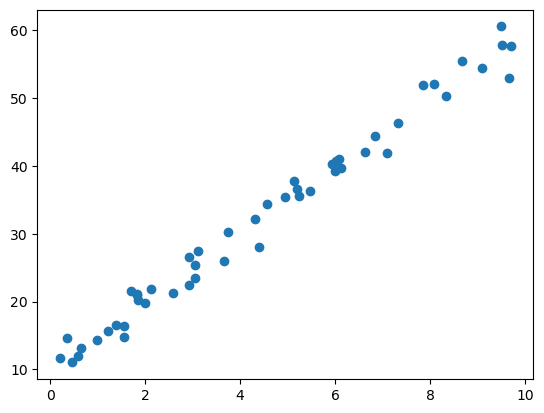

In [15]:
hourList = torch.tensor(df['study_hours'].values) # x axis
gradeList = torch.tensor(df['grade'].values) #y axis

plt.scatter(x=hourList, y=gradeList)
plt.show()

### train - test split

In [23]:
train_split = int(len(hourList) * 0.8)
X_train, Y_train = hourList[:train_split], gradeList[:train_split]
X_test, Y_test = hourList[train_split:], gradeList[train_split:]

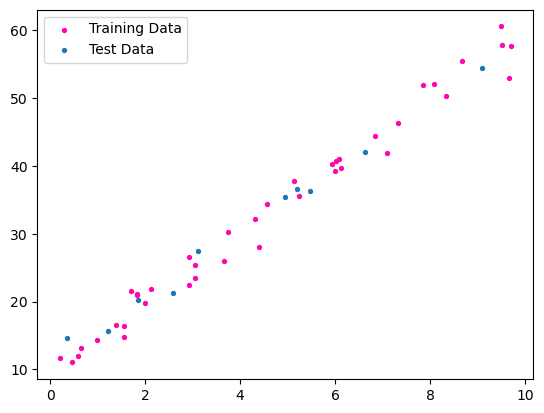

In [38]:
plt.scatter(x=X_train, y=Y_train, label="Training Data", c="#ff08ac", s=8)
plt.scatter(x=X_test, y=Y_test, label="Test Data", s=8)
plt.legend()

plt.show()

In [93]:
from torch import nn # Neural Network

class SimpleLinearRegressionModel(nn.Module):

    def __init__(self):
        super().__init__()

        # self.linear= nn.Linear()
        self.weights = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)
        self.bias = nn.Parameter(torch.randn(1, dtype=torch.float), requires_grad=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # return linear(x)
        return self.weights * x + self.bias
        

In [94]:
torch.manual_seed(42)

firstModel = SimpleLinearRegressionModel()
# firstModel = torch.compile(firstModel) # For Optimizing

In [95]:
list(firstModel.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [96]:
firstModel.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

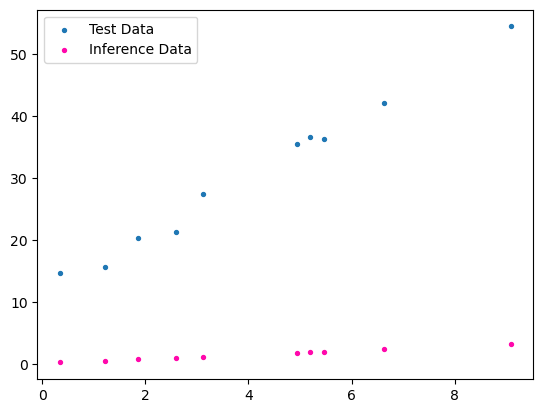

In [97]:
with torch.inference_mode():
    inference = firstModel(X_test)
    plt.scatter(x=X_test, y=Y_test, label="Test Data", s=8)
    plt.scatter(x=X_test, y=inference, label="Inference Data", c="#ff08ac", s=8)
    plt.legend()
    plt.show()

In [98]:
loss_fn = nn.MSELoss()
optimizer = torch.optim.SGD(params = firstModel.parameters(), lr = 0.0005)

In [99]:
torch.manual_seed(42)

epochs = 200
train_loss_values = []
test_loss_values = []
epoch_count = []

for epoch in range(epochs):
    firstModel.train()

    Y_pred = firstModel(X_train)

    loss = loss_fn(Y_pred,Y_train)

    optimizer.zero_grad() # delete the informations from previous epoch
    loss.backward() # calculate derivative
    optimizer.step() # calculate weights again

    firstModel.eval()

    with torch.inference_mode():
        test_pred = firstModel(X_test)
        test_loss = loss_fn(test_pred, Y_test)

        if epoch % 5 == 0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())

            print(f"Epoch: {epoch}, Train Loss: {loss}, Test Loss: {test_loss}")
        


Epoch: 0, Train Loss: 1156.0767463081781, Test Loss: 910.6837559428893
Epoch: 5, Train Loss: 858.8601464028106, Test Loss: 684.5814292826751
Epoch: 10, Train Loss: 639.801222266819, Test Loss: 517.210814558006
Epoch: 15, Train Loss: 478.3427737501057, Test Loss: 393.22704823709296
Epoch: 20, Train Loss: 359.33477112006557, Test Loss: 301.30650866624853
Epoch: 25, Train Loss: 271.61182692794256, Test Loss: 233.09145182016513
Epoch: 30, Train Loss: 206.94539322390966, Test Loss: 182.41154141700352
Epoch: 35, Train Loss: 159.27114389228237, Test Loss: 144.7101547077538
Epoch: 40, Train Loss: 124.11982728181337, Test Loss: 116.62116465705208
Epoch: 45, Train Loss: 98.19769941334815, Test Loss: 95.657077137175
Epoch: 50, Train Loss: 79.07729714663316, Test Loss: 79.97879840015067
Epoch: 55, Train Loss: 64.96963932393501, Test Loss: 68.22598521256252
Epoch: 60, Train Loss: 54.55635113708432, Test Loss: 59.391849854102325
Epoch: 65, Train Loss: 46.86579278693442, Test Loss: 52.730702948305215

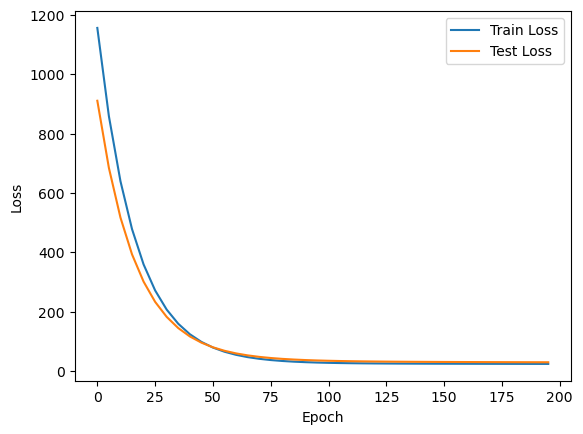

In [100]:
plt.plot(epoch_count, train_loss_values, label="Train Loss")
plt.plot(epoch_count, test_loss_values, label="Test Loss")
plt.legend()
plt.ylabel("Loss")
plt.xlabel("Epoch")
plt.show()

In [101]:
firstModel.state_dict()

OrderedDict([('weights', tensor([6.3031])), ('bias', tensor([1.5649]))])

In [102]:
firstModel.eval()
with torch.inference_mode():
    y_preds = firstModel(X_test)

In [103]:
X_test

tensor([1.2204, 4.9518, 0.3439, 9.0932, 2.5878, 6.6252, 3.1171, 5.2007, 5.4671,
        1.8485], dtype=torch.float64)

In [104]:
y_preds

tensor([ 9.2571, 32.7766,  3.7324, 58.8807, 17.8762, 43.3246, 21.2125, 34.3455,
        36.0248, 13.2165], dtype=torch.float64)

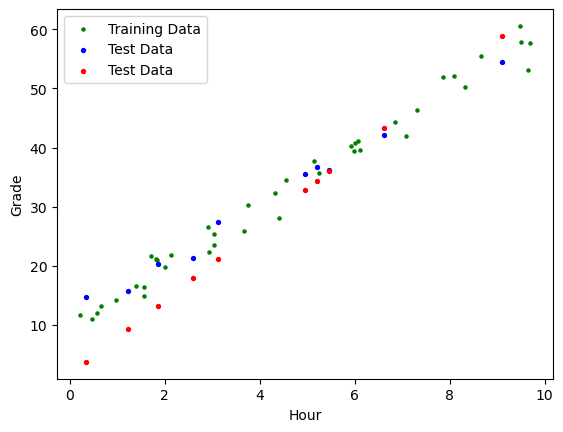

In [105]:
plt.scatter(X_train, Y_train, c="g", s=5, label="Training Data")
plt.scatter(X_test, Y_test, c="b", s=8, label="Test Data")
plt.scatter(X_test, y_preds, c="r", s=8, label="Test Data")
plt.xlabel("Hour")
plt.ylabel("Grade")
plt.legend()
plt.show()